-----------------------------------------------------------------
MÉTODO / VARIABLE         | A f = 41.0 kHz   | A f = 73.0 kHz  
-----------------------------------------------------------------
Lagrange 2° - V(f)        | 0.7946 V         | 0.3438 V
Spline Cúbico - V(f)      | 0.7923 V         | 0.3442 V
-----------------------------------------------------------------
Lagrange 2° - |Z(f)|      | 146.2920 Ω       | 203.5920 Ω
Spline Cúbico - |Z(f)|    | 146.2860 Ω       | 203.5888 Ω
-----------------------------------------------------------------


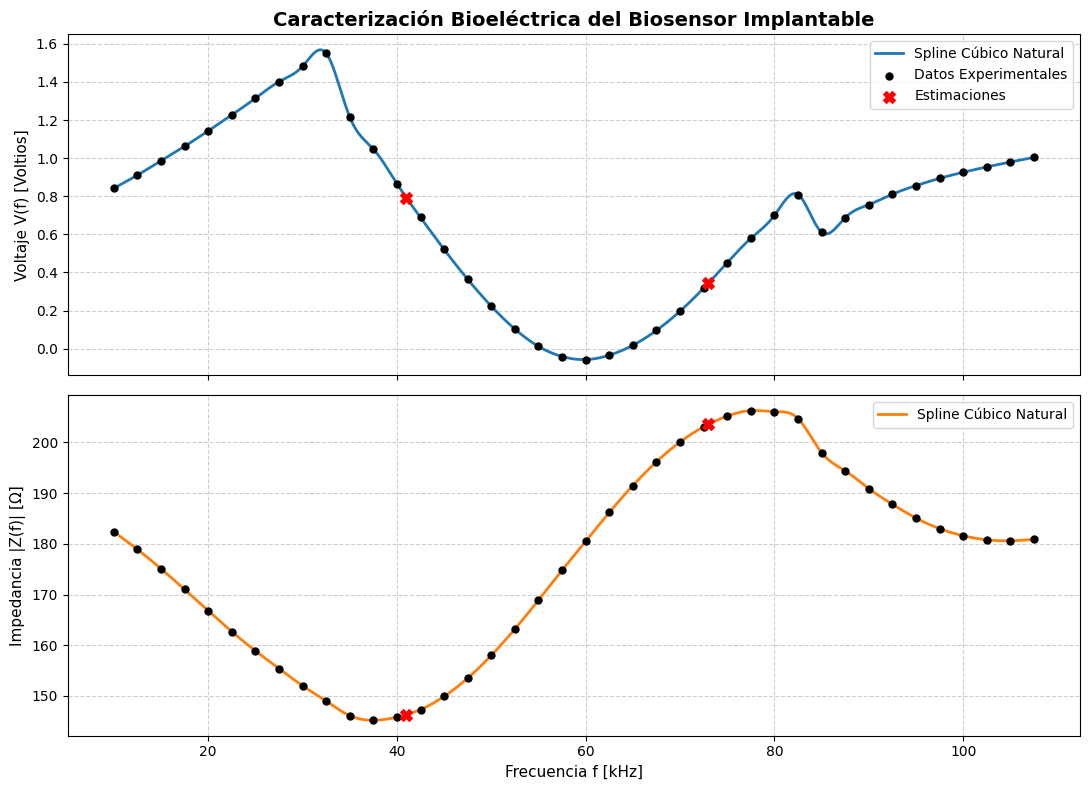

In [1]:
# ==============================================================================
# EXAMEN PARCIAL DE MÉTODOS NUMÉRICOS - PARTE 1: INTERPOLACIÓN
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1. Ingreso de los 40 datos experimentales del ensayo
f_data = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5,
    45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0,
    77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])

V_data = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689,
    0.521, 0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452,
    0.579, 0.700, 0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])

Z_data = np.array([
    182.4, 178.9, 175.1, 171.0, 166.8, 162.7, 158.9, 155.4, 152.0, 149.0, 146.1, 145.2, 145.8, 147.3,
    149.9, 153.5, 158.0, 163.2, 168.9, 174.8, 180.5, 186.2, 191.5, 196.2, 200.1, 203.1, 205.2,
    206.3, 206.1, 204.7, 198.0, 194.4, 190.9, 187.8, 185.1, 183.0, 181.6, 180.8, 180.6, 180.9
])

# Funciones analíticas para la interpolación de Lagrange de 2do Grado (3 puntos)
def lagrange_2do_grado(x_target, x_pts, y_pts):
    L0 = ((x_target - x_pts[1]) * (x_target - x_pts[2])) / ((x_pts[0] - x_pts[1]) * (x_pts[0] - x_pts[2]))
    L1 = ((x_target - x_pts[0]) * (x_target - x_pts[2])) / ((x_pts[1] - x_pts[0]) * (x_pts[1] - x_pts[2]))
    L2 = ((x_target - x_pts[0]) * (x_target - x_pts[1])) / ((x_pts[2] - x_pts[0]) * (x_pts[2] - x_pts[1]))
    return L0 * y_pts[0] + L1 * y_pts[1] + L2 * y_pts[2]

# --- Estimación para f = 41.0 kHz ---
# Puntos más cercanos en la tabla: idx 11, 12, 13 -> 37.5, 40.0, 42.5
idx_41 = [11, 12, 13]
V_lag_41 = lagrange_2do_grado(41.0, f_data[idx_41], V_data[idx_41])
Z_lag_41 = lagrange_2do_grado(41.0, f_data[idx_41], Z_data[idx_41])

# --- Estimación para f = 73.0 kHz ---
# Puntos más cercanos en la tabla: idx 24, 25, 26 -> 70.0, 72.5, 75.0
idx_73 = [24, 25, 26]
V_lag_73 = lagrange_2do_grado(73.0, f_data[idx_73], V_data[idx_73])
Z_lag_73 = lagrange_2nd_degree = lagrange_2do_grado(73.0, f_data[idx_73], Z_data[idx_73])

# 2. Construcción de Splines Cúbicos Naturales
cs_V = CubicSpline(f_data, V_data, bc_type='natural')
cs_Z = CubicSpline(f_data, Z_data, bc_type='natural')

V_spl_41 = cs_V(41.0)
Z_spl_41 = cs_Z(41.0)
V_spl_73 = cs_V(73.0)
Z_spl_73 = cs_Z(73.0)

# Imprimir Resultados en Consola
print("-" * 65)
print(f"{'MÉTODO / VARIABLE':<25} | {'A f = 41.0 kHz':<16} | {'A f = 73.0 kHz':<16}")
print("-" * 65)
print(f"{'Lagrange 2° - V(f)':<25} | {V_lag_41:.4f} V         | {V_lag_73:.4f} V")
print(f"{'Spline Cúbico - V(f)':<25} | {V_spl_41:.4f} V         | {V_spl_73:.4f} V")
print("-" * 65)
print(f"{'Lagrange 2° - |Z(f)|':<25} | {Z_lag_41:.4f} \u03a9       | {Z_lag_73:.4f} \u03a9")
print(f"{'Spline Cúbico - |Z(f)|':<25} | {Z_spl_41:.4f} \u03a9       | {Z_spl_73:.4f} \u03a9")
print("-" * 65)

# 3. Generación de Gráficas Profesionales de Control
f_dense = np.linspace(10.0, 107.5, 1000)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Gráfica de Voltaje
ax1.plot(f_dense, cs_V(f_dense), color='#1f77b4', label='Spline Cúbico Natural', lw=2)
ax1.scatter(f_data, V_data, color='black', s=25, label='Datos Experimentales', zorder=3)
ax1.scatter([41.0, 73.0], [V_spl_41, V_spl_73], color='red', s=70, marker='X', label='Estimaciones', zorder=4)
ax1.set_ylabel('Voltaje V(f) [Voltios]', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')
ax1.set_title('Caracterización Bioeléctrica del Biosensor Implantable', fontsize=14, fontweight='bold')

# Gráfica de Impedancia
ax2.plot(f_dense, cs_Z(f_dense), color='#ff7f0e', label='Spline Cúbico Natural', lw=2)
ax2.scatter(f_data, Z_data, color='black', s=25, zorder=3)
ax2.scatter([41.0, 73.0], [Z_spl_41, Z_spl_73], color='red', s=70, marker='X', zorder=4)
ax2.set_xlabel('Frecuencia f [kHz]', fontsize=11)
ax2.set_ylabel('Impedancia |Z(f)| [\u03a9]', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Frecuencia (f)   | Dif. Centrada O(2) | Dif. Centrada O(4) | Derivada Spline 
10.0 kHz (Prog)  | 0.026400           | N/A                | 0.026953        
40.0 kHz         | -0.071800          | -0.072567          | -0.076862       
70.0 kHz         | 0.044400           | 0.044733           | 0.044657        
100.0 kHz        | 0.012000           | 0.011867           | 0.011805        


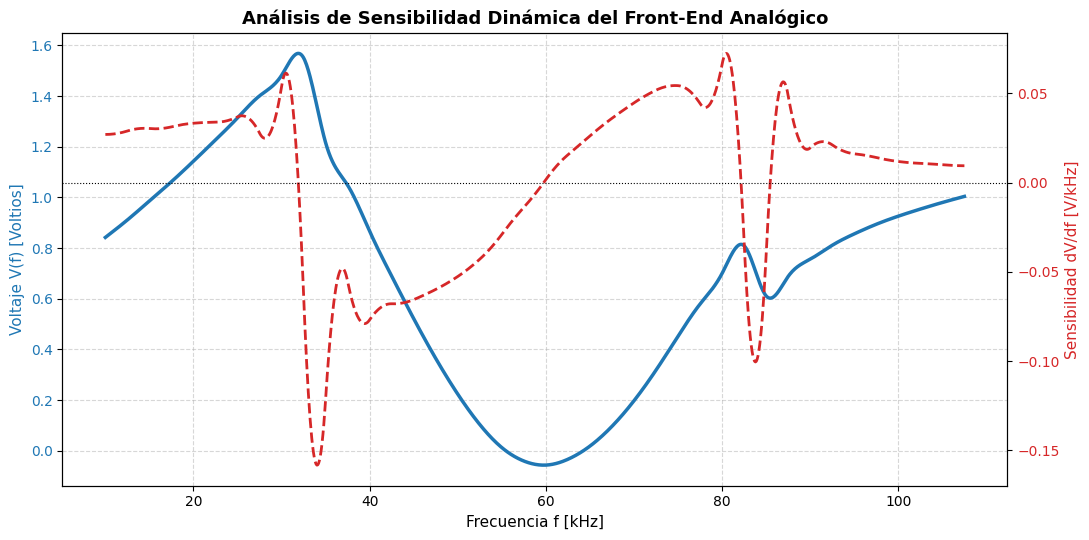

In [2]:
# ==============================================================================
# EXAMEN PARCIAL DE MÉTODOS NUMÉRICOS - PARTE 2: DERIVACIÓN NUMÉRICA
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Re-declaramos los datos base por seguridad
f_data = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5,
    45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0,
    77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V_data = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689,
    0.521, 0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452,
    0.579, 0.700, 0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])
h = 2.5  # Paso constante en kHz

# Inicializar objeto Spline Cúbico Natural y su derivada analítica
cs_V = CubicSpline(f_data, V_data, bc_type='natural')
cs_deriv = cs_V.derivative()

# Función para diferencias finitas centradas O(2) y O(4)
def calcular_diferencias_centradas(f_val):
    idx = np.where(f_data == f_val)[0][0]
    # Orden 2
    dO2 = (V_data[idx + 1] - V_data[idx - 1]) / (2 * h)
    # Orden 4
    dO4 = (-V_data[idx + 2] + 8*V_data[idx + 1] - 8*V_data[idx - 1] + V_data[idx - 2]) / (12 * h)
    return dO2, dO4

# Evaluaciones requeridas
dO2_40, dO4_40 = calcular_diferencias_centradas(40.0)
dO2_70, dO4_70 = calcular_diferencias_centradas(70.0)
dO2_100, dO4_100 = calcular_diferencias_centradas(100.0)

# Extremo inferior f = 10.0 kHz (Fórmula progresiva O(2))
# f'(x) = (-3*f(x) + 4*f(x+h) - f(x+2h)) / (2*h)
d_prog_10 = (-3*V_data[0] + 4*V_data[1] - V_data[2]) / (2 * h)

# Impresión de Reporte Técnico en Consola
print("=" * 75)
print(f"{'Frecuencia (f)':<16} | {'Dif. Centrada O(2)':<18} | {'Dif. Centrada O(4)':<18} | {'Derivada Spline':<16}")
print("=" * 75)
print(f"{'10.0 kHz (Prog)':<16} | {d_prog_10:<18.6f} | {'N/A':<18} | {cs_deriv(10.0):<16.6f}")
print(f"{'40.0 kHz':<16} | {dO2_40:<18.6f} | {dO4_40:<18.6f} | {cs_deriv(40.0):<16.6f}")
print(f"{'70.0 kHz':<16} | {dO2_70:<18.6f} | {dO4_70:<18.6f} | {cs_deriv(70.0):<16.6f}")
print(f"{'100.0 kHz':<16} | {dO2_100:<18.6f} | {dO4_100:<18.6f} | {cs_deriv(100.0):<16.6f}")
print("=" * 75)

# --- Gráfica Profesional Doble Eje (Voltaje vs Sensibilidad) ---
f_dense = np.linspace(10.0, 107.5, 1000)

fig, ax1 = plt.subplots(figsize=(11, 5.5))

color = '#1f77b4'
ax1.set_xlabel('Frecuencia f [kHz]', fontsize=11)
ax1.set_ylabel('Voltaje V(f) [Voltios]', color=color, fontsize=11)
ax1.plot(f_dense, cs_V(f_dense), color=color, lw=2.5, label='Curva de Voltaje V(f)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Sensibilidad dV/df [V/kHz]', color=color, fontsize=11)
ax2.plot(f_dense, cs_deriv(f_dense), color=color, lw=2, linestyle='--', label='Sensibilidad dV/df')
ax2.axhline(0, color='black', lw=0.8, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Análisis de Sensibilidad Dinámica del Front-End Analógico', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


PROCESO DE BISECCIÓN: Primer Cruce (Modelo Lineal)
------------------------------------------------------------
Iter  | Eje a (kHz) | Eje b (kHz) | Punto m (kHz) | V(m) [Voltios]
------------------------------------------------------------
1     | 55.0000     | 57.5000     | 56.2500      | -0.014500   
2     | 55.0000     | 56.2500     | 55.6250      | -0.001250   
3     | 55.0000     | 55.6250     | 55.3125      | 0.005375    
4     | 55.3125     | 55.6250     | 55.4688      | 0.002062    
5     | 55.4688     | 55.6250     | 55.5469      | 0.000406    
6     | 55.5469     | 55.6250     | 55.5859      | -0.000422   

PROCESO DE BISECCIÓN: Segundo Cruce (Modelo Lineal)
------------------------------------------------------------
Iter  | Eje a (kHz) | Eje b (kHz) | Punto m (kHz) | V(m) [Voltios]
------------------------------------------------------------
1     | 62.5000     | 65.0000     | 63.7500      | -0.008000   
2     | 63.7500     | 65.0000     | 64.3750      | 0.005000    
3    

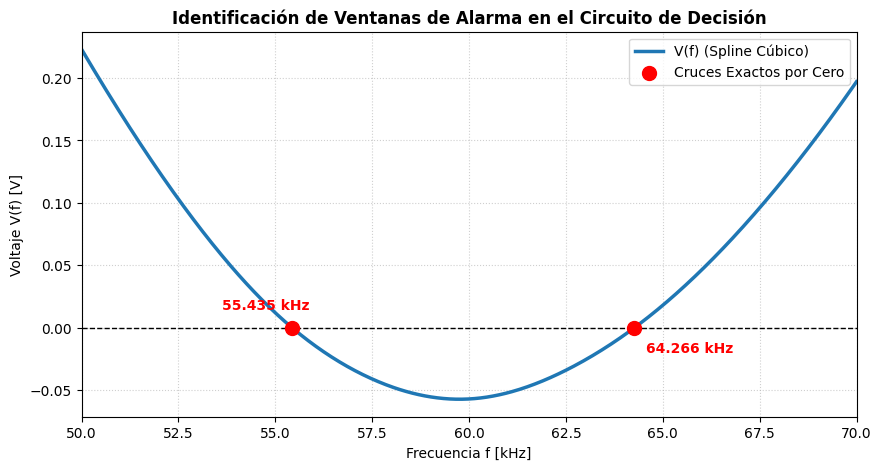

In [3]:
# ==============================================================================
# EXAMEN PARCIAL DE MÉTODOS NUMÉRICOS - PARTE 3: DETERMINACIÓN DE RAÍCES
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import fsolve

# Datos base del ensayo
f_data = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5,
    45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0,
    77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5, 95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])
V_data = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689,
    0.521, 0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452,
    0.579, 0.700, 0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])

# Inicializar Spline
cs_V = CubicSpline(f_data, V_data, bc_type='natural')

# 1. Definición del Algoritmo Manual de Bisección (6 iteraciones de control)
def ejecutar_biseccion_reporte(func, a, b, label):
    print(f"\nPROCESO DE BISECCIÓN: {label}")
    print("-" * 60)
    print(f"{'Iter':<5} | {'Eje a (kHz)':<11} | {'Eje b (kHz)':<11} | {'Punto m (kHz)':<12} | {'V(m) [Voltios]':<12}")
    print("-" * 60)

    for i in range(1, 7):
        m = (a + b) / 2.0
        vm = func(m)
        print(f"{i:<5} | {a:<11.4f} | {b:<11.4f} | {m:<12.4f} | {vm:<12.6f}")

        if np.sign(func(a)) == np.sign(vm):
            a = m
        else:
            b = m
    return m

# Modelos Lineales Locales (Bisección Directa sobre la Tabla)
V_lineal_1 = lambda f: 0.012 + ((-0.041 - 0.012) / 2.5) * (f - 55.0)
V_lineal_2 = lambda f: -0.034 + ((0.018 - (-0.034)) / 2.5) * (f - 62.5)

# Ejecución para los dos intervalos identificados
root1_tab = ejecutar_biseccion_reporte(V_lineal_1, 55.0, 57.5, "Primer Cruce (Modelo Lineal)")
root2_tab = ejecutar_biseccion_reporte(V_lineal_2, 62.5, 65.0, "Segundo Cruce (Modelo Lineal)")

# 2. Refinamiento de raíces con Spline Cúbico Global
root1_spl = fsolve(cs_V, 55.4)[0]
root2_spl = fsolve(cs_V, 64.2)[0]

print("\n" + "="*60)
print("REPORTE COMPARATIVO DE COMPORTAMIENTO")
print("="*60)
print(f"Raíz 1 (Cruce 1) -> Lineal Tabla: {root1_tab:.4f} kHz | Refinado Spline: {root1_spl:.4f} kHz")
print(f"Raíz 2 (Cruce 2) -> Lineal Tabla: {root2_tab:.4f} kHz | Refinado Spline: {root2_spl:.4f} kHz")
print("="*60)

# 3. Gráfica de Inspección de Raíces
f_dense = np.linspace(50.0, 70.0, 500)
plt.figure(figsize=(10, 5))
plt.plot(f_dense, cs_V(f_dense), color='#1f77b4', lw=2.5, label='V(f) (Spline Cúbico)')
plt.axhline(0, color='black', lw=1, linestyle='--')

# Dibujar las raíces refinadas
plt.scatter([root1_spl, root2_spl], [0, 0], color='red', s=100, zorder=5, label='Cruces Exactos por Cero')
plt.text(root1_spl - 1.8, 0.015, f"{root1_spl:.3f} kHz", color='red', weight='bold')
plt.text(root2_spl + 0.3, -0.02, f"{root2_spl:.3f} kHz", color='red', weight='bold')

plt.title('Identificación de Ventanas de Alarma en el Circuito de Decisión', fontsize=12, fontweight='bold')
plt.xlabel('Frecuencia f [kHz]')
plt.ylabel('Voltaje V(f) [V]')
plt.xlim(50, 70)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()